In [1]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
import rasterio

In [56]:
def line_in_disk(angle, radius=50, linelength=10, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = np.exp(-(x**2 + y**2) / 2 / linelength**2) / np.sqrt(2 * np.pi * linelength**2)
    line = np.abs(x * np.sin(-angle * np.pi/180) - y * np.cos(angle * np.pi/180)) < linewidth
    centerline = minidisk * (disk & line)
    big = -(disk / np.sum(disk)) + (centerline / np.sum(centerline))
    small = np.sum(np.sum(big.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    return small

5.273559366969494e-16


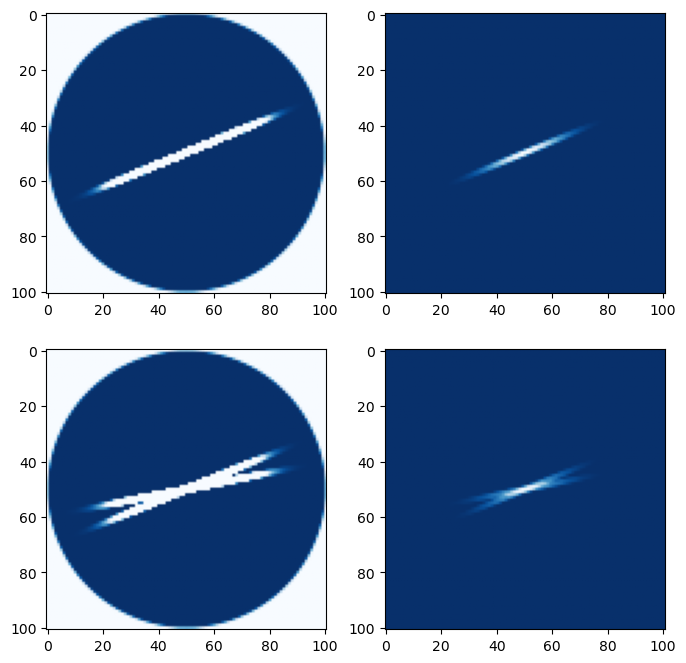

In [3]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

tmp = line_in_disk(22.5)
tmp2 = line_in_disk(11.25)
print(np.sum(tmp))

ax1.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")
ax2.imshow(tmp, vmin=0, vmax=np.nanmax(tmp), cmap="Blues_r")
ax3.imshow(tmp + tmp2, vmin=np.nanmin(tmp + tmp2), vmax=0, cmap="Blues_r")
ax4.imshow(tmp + tmp2, vmin=0, vmax=np.nanmax(tmp + tmp2), cmap="Blues_r")

None

In [88]:
multikernel = np.stack([line_in_disk(angle) for angle in np.arange(0, 180, 11.25)])

In [4]:
with rasterio.open("../data/Sonoma_DTM_2022-OAEC-0.01-degree.tif") as file:
    elevation = file.read(1)
    transform = file.transform
    crs = file.crs
    left, bottom, right, top = file.bounds

In [101]:
_convolve2dkernel = {}

def convolve2d(image, multikernel):
    output = np.zeros(image.shape + multikernel.shape[:1], image.dtype)

    key = (image.shape, multikernel.shape)
    if key not in _convolve2dkernel:
        imageI, imageJ = image.shape
        kernelI, kernelJ = multikernel.shape[1:]
        num_angles = multikernel.shape[0]

        @nb.jit(parallel=True)
        def fcn(image, multikernel, output):
            for imi in nb.prange(imageI):
                for imj in nb.prange(imageJ):
                    halfi = kernelI // 2
                    halfj = kernelJ // 2

                    for ang in range(num_angles):
                        accumulate = 0
                        for ki in range(kernelI):
                            for kj in range(kernelJ):
                                i = imi + ki - halfi
                                j = imj + kj - halfj
                                # boundary conditions that reflect
                                before = j
                                if i < 0:
                                    i = -i
                                elif i >= imageI:
                                    i = 2*imageI - i - 1
                                if j < 0:
                                    j = -j
                                elif j >= imageJ:
                                    j = 2*imageJ - j - 1
                                accumulate += image[i, j] * multikernel[ang, ki, kj]

                        output[imi, imj, ang] = accumulate

        _convolve2dkernel[key] = fcn

    _convolve2dkernel[key](image, multikernel, output)
    return output

In [ ]:
result = convolve2d(elevation, multikernel)

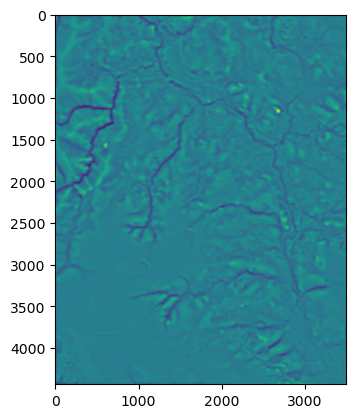

In [62]:
fig, ax = plt.subplots()

ax.imshow(result[:, :, 0])

None